In [1]:
import numpy as np
import itertools
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import Aer
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor


## Optimizer

In [2]:
class Optimizer():
    """
    Base class for all optimizers
    """
    def update(self, w: dict, grad: dict) -> dict:
        pass


class SGD(Optimizer):
    def __init__(self, lr: float):
        """
        SGD optimizer

        Args:
            lr: learning rate
        """
        self.lr = lr

    def update(self, w: dict, grad: dict) -> dict:
        """
        Update weight

        Args:
            w: weight
            grad: gradient
        """
        for key, value in w.items():
            w[key] -= self.lr * grad[key]


        return w
    
class Momentum(Optimizer):
    def __init__(self, lr: float, gamma: float = 0.9):
        """
        Momentum optimizer

        Args:
            lr: learning rate
            gamma: momentum coefficient
        """
        self.lr = lr
        self.gamma = gamma
        self.v = None  # Velocity

    def update(self, w: dict, grad: dict) -> dict:
        """
        Update weight

        Args:
            w: weight
            grad: gradient
        """

        # If this is the first iteration, initialize v with zeros with same shape as w
        if self.v is None:
            self.v = {
                key: np.zeros_like(value) for key, value in w.items()
            }

        for key, value in self.v.items():
            self.v[key] += self.lr * grad[key]
            w[key] -= self.v[key] 

        return w

## Circuits

In [ ]:
class BrickWallCircuit():
    def __init__(self, n_qubits, num_layers, num_RZZ=None, gate_type = None, para=None):


        self.get_key_local = lambda i,j : "{}-layer {}-index local".format(i, j)
        self.get_key_CZ = lambda i,j : "{}-layer {}-index CZ".format(i, j)
        self.get_key_gate_type = lambda i,j : "{}-layer {}-index gate type".format(i,j)

        self.n_qubits = n_qubits
        self.num_layers = num_layers

        if gate_type is not None:
            self.gate_type = gate_type
        elif gate_type is None and num_RZZ is not None:
            self.generate_gate_type(num_RZZ)
        else:
            self.generate_gate_type(2)
        if para is None:
            self.generate_parameters()
        else:
            self.para = para
        self._build()

    def _build(self):
        self.circuit = QuantumCircuit(self.n_qubits)
        for layer in range(self.num_layers):
            self._Layer(layer)

    def _Layer(self, layer_index):

        index = [2*i for i in range((self.n_qubits // 2))] if layer_index % 2 == 0 else [2*i+1 for i in range((self.n_qubits-1) // 2 )]

        for i in range(len(index)):
            local_para = self.para[self.get_key_local(layer_index, index[i])]
            Rzz_para = self.para[self.get_key_CZ(layer_index, index[i])]
            num_RZZ = self.gate_type[self.get_key_gate_type(layer_index, index[i])]
            
            self._bricks(local_para, num_RZZ, Rzz_para, index[i])
    
    def _bricks(self, local_para, num_RZZ, Rzz_para, index):
        q0_para = local_para[0, :]
        q1_para = local_para[1, :]

        self._local(q0_para, index)
        self._local(q1_para, index+1)

        for i in range(num_RZZ):
            q0_para = local_para[2*i+2, :]
            q1_para = local_para[2*i+3, :]

            self.circuit.rzz(Rzz_para[i],index,index+1)
            self._local(q0_para, index)
            self._local(q1_para, index+1)

    def _local(self, para, index):
        self.circuit.rz(para[0], index)
        self.circuit.rx(para[1], index)
        self.circuit.rz(para[2], index)

    def generate_parameters(self):
        """
        This function generates random parameters for the circuit automatically.
        Given gate_type, it generates parameters for the gate of the circuit.
        The parameters are stored in self.para which is a dictionary.
        """
        self.para = {}
        for i in range(self.num_layers):
            if i % 2 == 0:
                num_index = self.n_qubits//2
                index = [2*j for j in range(num_index)]
            else:
                num_index = (self.n_qubits-1)//2
                index = [2*j+1 for j in range(num_index)]
    

            for k in range(num_index):
                #print("Generate parameters for the gate of the {}-th layer and the {}-th qutrits.".format(i, k))
                temp_para = np.random.random((2*self.gate_type[self.get_key_gate_type(i,index[k])]+2, 3)) * np.pi * 2
                temp_Rzz_para = np.random.random(self.gate_type[self.get_key_gate_type(i,index[k])])* np.pi * 2 if self.gate_type[self.get_key_gate_type(i,index[k])] > 0 else None
    
                self.para[self.get_key_local(i,index[k])] = temp_para
                self.para[self.get_key_CZ(i,index[k])] = temp_Rzz_para

    def generate_gate_type(self, num_RZZ):
        """
        This function generates gate_tyep for the circuit automatically.
        Given the number of CZ gates, it generates parameters for the gate of the circuit.
        The parameters are stored in self.para which is a dictionary.
        """
        self.gate_type = {}
        for i in range(self.num_layers):
            if i % 2 == 0:
                num_index = self.n_qubits//2
                index = [2*j for j in range(num_index)]
            else:
                num_index = (self.n_qubits-1)//2
                index = [2*j+1 for j in range(num_index)]
    
            for k in range(num_index):
                self.gate_type[self.get_key_gate_type(i, index[k])] = num_RZZ

class test_circuit():
    def __init__(self, para):
        self.para = para
        self._build()

    def _build(self):
        self.circuit = QuantumCircuit(2)
        self.circuit.cx(0,1)
        self.circuit.rz(self.para.get("para")[2], 0)
        self.circuit.ry(self.para.get("para")[1], 1)
        self.circuit.ry(self.para.get("para")[0], 0)


In [ ]:
class EntanglementDetection:
    def __init__(self, target_state_circuit, 
                test_state_circuit_config, 
                optimizer, 
                n_qubits=2, 
                mode='partial_transpose', 
                use_parallel=False,
                backend=None,
                ):
        """
        Initialize VED for entanglement detection
        
        Args:
            target_state_circuit: Circuit preparing the target state to test
            n_qubits_A: Number of qubits in subsystem A
            n_qubits_B: Number of qubits in subsystem B
            mode: Type of positive map
        """
        self.n_qubits = n_qubits
        self.target_state_circuit = target_state_circuit
        self.mode = mode
        self.backend = Aer.get_backend("aer_simulator") if backend is None else backend
        self.use_parallel = use_parallel
        self.optimizer = optimizer
        
        # Store Pauli strings and coefficients
        self.PauliString = {}
        self.PauliStringQC = {}
        self.test_state_circuit = BrickWallCircuit(n_qubits=n_qubits, **test_state_circuit_config)
        # self.test_state_circuit = test_circuit(test_state_circuit_config)
        
        # Initialize Pauli decomposition
        self._setup_pauli_decomposition()
        self._create_pauli_circuits()
        
    def _setup_pauli_decomposition(self):
        """Setup Pauli string decomposition based on the chosen map"""
        
        if self.mode == 'partial_transpose':
            # Generate all Pauli strings for subsystem B
            self._generate_partial_transpose_decomposition()
            
        elif self.mode == 'reduction':
            self._generate_reduction_decomposition()
    
    def _generate_partial_transpose_decomposition(self):
        """
        Generate Pauli decomposition for partial transpose on subsystem B
        T_B = ⊗_i (I + X_i - Y_i + Z_i)/2
        """
        # Single qubit coefficients for transpose
        single_qubit_coeffs = {
            'I': 1,
            'X': 1,
            'Y': -1,  # Negative!
            'Z': 1
        }
        
        pauli_ops = ['I', 'X', 'Y', 'Z']
        
        # Generate all Pauli strings for subsystem B
        for pauli_combo_B in itertools.product(pauli_ops, repeat=int(self.n_qubits/2)):
            # Coefficient is product of individual coefficients
            coeff = 1.0 / (2**int(self.n_qubits/2))
            for pauli in pauli_combo_B:
                coeff *= single_qubit_coeffs[pauli]
            
            # Create full Pauli string (Identity on A, Pauli on B)
            pauli_string_A = 'I' * int(self.n_qubits/2)
            pauli_string_B = ''.join(pauli_combo_B)
            full_pauli_string = pauli_string_A + pauli_string_B
            
            self.PauliString[full_pauli_string] = coeff
    
    def _generate_reduction_decomposition(self):
        """
        Generate Pauli decomposition for reduction map on subsystem B
        R_B = (-I + X + Y + Z)/2 for each qubit
        """
        pauli_ops = ['I', 'X', 'Y', 'Z']
        
        for pauli_combo_B in itertools.product(pauli_ops, repeat=int(self.n_qubits/2)):
            coeff = 1.0 / (2**int(self.n_qubits/2))
            
            pauli_string_A = 'I' * int(self.n_qubits/2)
            pauli_string_B = ''.join(pauli_combo_B)
            full_pauli_string = pauli_string_A + pauli_string_B
            
            self.PauliString[full_pauli_string] = coeff

        self.PauliString['I'*self.n_qubits] = 1/2**int(self.n_qubits/2) - 1

    def _generate_enhanced_reduction_decomposition(self):
        pauli_ops = ['I', 'X', 'Y', 'Z']

    
    def _create_pauli_circuits(self):
        """Create quantum circuits for each Pauli string"""
        
        for pauli_string, coeff in self.PauliString.items():
            qc = QuantumCircuit(self.n_qubits)
            
            # Apply Pauli gates according to the string
            for qubit_idx, pauli_op in enumerate(pauli_string):
                if pauli_op == 'X':
                    qc.x(qubit_idx)
                elif pauli_op == 'Y':
                    qc.y(qubit_idx)
                elif pauli_op == 'Z':
                    qc.z(qubit_idx)
                # 'I' means no operation
            
            self.PauliStringQC[pauli_string] = qc
    
    def compute_overlap(self, pauli_string, test_state_circuit, shots):
        """
        Compute <ψ|O(ρ)|ψ> for a given Pauli string
        
        Uses the circuit: U†(α) · O · ρ · O† · U(α) |00...0>
        """
        # Create full circuit
        circuit = QuantumCircuit(self.n_qubits)
        
        # 1. Prepare target state ρ
        circuit.compose(self.target_state_circuit, inplace=True)
        
        # 2. Apply Pauli operation O
        circuit.compose(self.PauliStringQC[pauli_string], inplace=True)
        
        # 3. Apply U(α) - inverse of test state
        circuit.compose(test_state_circuit.circuit, inplace=True)
        
        # Add measurements
        circuit.measure_all()
        
        # Execute
        job = self.backend.run(circuit, shots=shots)
        result = job.result()
        counts = result.get_counts()
        
        # Get probability of |00...0>
        all_zeros = '0' * self.n_qubits
        overlap = counts.get(all_zeros, 0) / shots
        
        return overlap
    
    def loss_function(self, test_state_circuit=None, shots=10000):
        """
        Compute loss L(α) = Σ r_O <ψ|O(ρ)|ψ>
        
        Returns:
            Loss value (negative indicates entanglement)
        """
        loss = 0.0
        if test_state_circuit is None:
            test_state_circuit = self.test_state_circuit
        
        for pauli_string, coeff in self.PauliString.items():
            # Skip very small coefficients for efficiency
            overlap = self.compute_overlap(pauli_string, test_state_circuit, shots=shots)
            loss += coeff * overlap
            
        return loss

    def compute_grad(self):
        """
        Improved gradient calculation using parameter shift rule
        """
        para = self.test_state_circuit.para
        grad_set = {key: np.zeros_like(value) for key, value in para.items()}
        
        # Pre-compute circuit creation function to avoid redundancy
        def create_circuit(modified_para):
            config = {
                "n_qubits":self.test_state_circuit.n_qubits,
                "num_layers":self.test_state_circuit.num_layers,
                "gate_type":self.test_state_circuit.gate_type,
                "para":modified_para
            }
            return BrickWallCircuit(
                **config
            )
            # return test_circuit(para=modified_para)
        
        # Flatten all parameters for easier iteration
        param_list = []
        for key, value in para.items():
            indices = np.ndindex(value.shape)
            for idx in indices:
                param_list.append((key, idx))
        
        # Option 1: Batch gradient computation
        if self.use_parallel:
            grad_results = self._parallel_grad_computation(para, param_list, create_circuit)
            
            # Unpack results
            for (key, idx), grad_val in grad_results:
                grad_set[key][idx] = grad_val
        else:
            # Option 2: Sequential with caching
            for key, idx in param_list:
                if np.random.randn(1) > 0.8:
                    grad_set[key][idx] = 0
                    continue
                grad_val = self._compute_single_gradient(para, key, idx, create_circuit)
                grad_set[key][idx] = grad_val
        
        return grad_set
    
    def _compute_single_gradient(self, para, key, idx, create_circuit):
        """
        Compute gradient for a single parameter
        """
        # Create shifted parameters
        para_plus = self._deep_copy_para(para)
        para_minus = self._deep_copy_para(para)
        
        # Apply parameter shift (π/2 for parameter shift rule)
        para_plus[key][idx] += np.pi/2
        para_minus[key][idx] -= np.pi/2
        

        # Create circuits
        qc_plus = create_circuit(para_plus)
        qc_minus = create_circuit(para_minus)
        
        # Compute gradient using parameter shift rule
        # For rotation gates: ∂L/∂θ = (L(θ+π/2) - L(θ-π/2))/2
        gradient = (self.loss_function(qc_plus) - self.loss_function(qc_minus)) / 2
        
        return gradient
    
    def _parallel_grad_computation(self, para, param_list, create_circuit):
        """
        Compute gradients in parallel
        """
        def compute_grad_task(param_info):
            key, idx = param_info
            return (param_info, self._compute_single_gradient(para, key, idx, create_circuit))
        
        with ProcessPoolExecutor(max_workers=4) as executor:
            results = list(executor.map(compute_grad_task, param_list))
        
        return results
    
    def _deep_copy_para(self, para):
        """
        Efficiently deep copy parameter dictionary
        """
        return {key: value.copy() for key, value in para.items()}

    def train(self, num_epoch=100):
        log = []
        para = self.test_state_circuit.para
        # print("start: ", self.loss_function())

        for epoch in range(num_epoch):
            loss = self.loss_function()
            grad = self.compute_grad()
            log.append(loss)
            # print(f"[Epoch {epoch}] Loss {loss:.4f}\npara {self.test_state_circuit.para}\ngrad {grad}")
            print(f"[Epoch {epoch}] Loss {loss:.4f} ")
            self.optimizer.update(w=para, grad=grad)
            self.test_state_circuit._build()
        return log

## Quick Example: PPT in Bell state

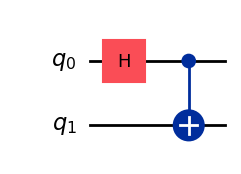

In [4]:
target_state_circuit = QuantumCircuit(2)
target_state_circuit.h(0)
target_state_circuit.cx(0,1)
target_state_circuit.draw("mpl")

In [5]:
test_state_circuit_config = {
    "num_layers":1, 
    "num_RZZ":1, 
    "gate_type": None, 
    "para": None
}

In [6]:
optimizer = SGD(lr=5e-1)
test = EntanglementDetection(target_state_circuit=target_state_circuit, test_state_circuit_config=test_state_circuit_config, optimizer=optimizer, n_qubits=2)
test.loss_function()
# 4.71238898, 3.14159265, 3.14159265
log = test.train(num_epoch=50)

[Epoch 0] Loss 0.4739 
[Epoch 1] Loss 0.4625 
[Epoch 2] Loss 0.4435 
[Epoch 3] Loss 0.4063 
[Epoch 4] Loss 0.3405 
[Epoch 5] Loss 0.2556 
[Epoch 6] Loss 0.1470 
[Epoch 7] Loss 0.0728 
[Epoch 8] Loss 0.0034 
[Epoch 9] Loss -0.0133 
[Epoch 10] Loss -0.0394 
[Epoch 11] Loss -0.0588 
[Epoch 12] Loss -0.0826 
[Epoch 13] Loss -0.1052 
[Epoch 14] Loss -0.1161 
[Epoch 15] Loss -0.1453 
[Epoch 16] Loss -0.1702 
[Epoch 17] Loss -0.2063 
[Epoch 18] Loss -0.2288 
[Epoch 19] Loss -0.2708 
[Epoch 20] Loss -0.3135 
[Epoch 21] Loss -0.3444 
[Epoch 22] Loss -0.3821 
[Epoch 23] Loss -0.4098 
[Epoch 24] Loss -0.4302 
[Epoch 25] Loss -0.4393 
[Epoch 26] Loss -0.4625 
[Epoch 27] Loss -0.4748 
[Epoch 28] Loss -0.4825 
[Epoch 29] Loss -0.4877 
[Epoch 30] Loss -0.4888 
[Epoch 31] Loss -0.4926 
[Epoch 32] Loss -0.4965 
[Epoch 33] Loss -0.4980 
[Epoch 34] Loss -0.4991 
[Epoch 35] Loss -0.4991 
[Epoch 36] Loss -0.4994 
[Epoch 37] Loss -0.4994 
[Epoch 38] Loss -0.4997 
[Epoch 39] Loss -0.4998 
[Epoch 40] Loss -0.

## Fig5 Reproduction

## Fig6 Reproduction

In [ ]:
target_state_circuit = QuantumCircuit(2)
target_state_circuit.h(0)
target_state_circuit.cx(0,1)
target_state_circuit
target_state_circuit.draw("mpl")